# Bayesian Portfolio Optimization
## Black-Litterman, Normal-Wishart Priors, and Closed-Form Efficient Frontiers

---

This notebook implements and analyses a complete Bayesian portfolio optimization framework:
1. **Theoretical background** — Markowitz, Normal-Wishart conjugacy, Black-Litterman
2. **Prior sensitivity analysis** — how kappa_0 shapes posterior estimates
3. **Black-Litterman with views** — view construction and confidence sensitivity
4. **Covariance estimator comparison** — Sample vs. LW vs. Normal-Wishart
5. **Efficient frontier comparison** — four estimators on shared axes
6. **Walk-forward evaluation** — out-of-sample Sharpe with Diebold-Mariano tests
7. **Two-fund separation** — the Markowitz separation theorem
8. **Limitations** — critical discussion of model assumptions

In [1]:
# Global setup — run first
import warnings
import sys
import os

# Ensure project root is on path for data/fetch.py
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from bayesian_portfolio import (
    NormalWishartPrior, NormalWishartPosterior,
    BlackLitterman, implied_returns,
    SampleCovariance, LedoitWolfCovariance, NormalWishartCovariance,
    EfficientFrontier, FrontierComparison,
    min_variance_weights, max_sharpe_weights,
    WalkForwardEvaluator, diebold_mariano_test,
)
from data.fetch import fetch_universe_10, fetch_universe_30, UNIVERSE_10, UNIVERSE_30

warnings.filterwarnings('ignore')

# --- Consistent matplotlib style ---
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print('Setup complete.')
print(f'UNIVERSE_10: {UNIVERSE_10}')
print(f'UNIVERSE_30 (first 10): {UNIVERSE_30[:10]}')

Setup complete.
UNIVERSE_10: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD', 'GSG', 'VNQ']
UNIVERSE_30 (first 10): ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'CRM', 'JNJ', 'UNH', 'LLY', 'ABBV', 'MRK']


---
## Section 1: Theoretical Background

### 1.1 Markowitz Mean-Variance Optimisation (Lagrangian Derivation)

Given expected returns $\mu \in \mathbb{R}^n$ and covariance $\Sigma \in \mathbb{R}^{n\times n}$ (SPD), the **minimum-variance portfolio** targeting return $\mu^*$ solves:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mu^\top w = \mu^*, \quad \mathbf{1}^\top w = 1$$

Lagrangian: $\mathcal{L} = w^\top \Sigma w - \lambda_1(\mu^\top w - \mu^*) - \lambda_2(\mathbf{1}^\top w - 1)$

FOC: $2\Sigma w = \lambda_1 \mu + \lambda_2 \mathbf{1}$

This gives the **bordered Hessian** (KKT) system of size $(n+2)$:

$$\begin{bmatrix} 2\Sigma & \mathbf{1} & \mu \\ \mathbf{1}^\top & 0 & 0 \\ \mu^\top & 0 & 0 \end{bmatrix} \begin{bmatrix} w \\ \lambda_2 \\ \lambda_1 \end{bmatrix} = \begin{bmatrix} \mathbf{0} \\ 1 \\ \mu^* \end{bmatrix}$$

The **Two-Fund Separation Theorem** (Merton 1972) states that every efficient portfolio is a linear combination of any two distinct efficient portfolios — typically the global minimum-variance portfolio $w_{\text{mv}}$ and the tangency portfolio $w_{\text{ms}}$.

### 1.2 Normal-Wishart Conjugate Prior Derivation

Let $x_1, \ldots, x_T \overset{\text{iid}}{\sim} \mathcal{N}(\mu, \Sigma)$. Place a **Normal-Wishart** prior:

$$p(\mu, \Sigma) = \mathcal{N}(\mu \mid \mu_0, \Sigma/\kappa_0) \cdot \mathcal{W}^{-1}(\Sigma \mid \nu_0, \Psi_0)$$

The likelihood is:
$$p(X \mid \mu, \Sigma) \propto |\Sigma|^{-T/2} \exp\!\left(-\frac{1}{2}\mathrm{tr}\!\left[\Sigma^{-1}\left(S + T(\bar{x}-\mu)(\bar{x}-\mu)^\top\right)\right]\right)$$

where $S = \sum_t (x_t - \bar{x})(x_t - \bar{x})^\top$ is the scatter matrix. By conjugacy:

$$p(\mu, \Sigma \mid X) = \mathcal{NW}(\mu_n, \kappa_n, \nu_n, \Psi_n)$$

with closed-form updates:

$$\kappa_n = \kappa_0 + T, \quad \nu_n = \nu_0 + T$$
$$\mu_n = \frac{\kappa_0 \mu_0 + T\bar{x}}{\kappa_n}$$  
$$\Psi_n = \Psi_0 + S + \frac{\kappa_0 T}{\kappa_n}(\bar{x}-\mu_0)(\bar{x}-\mu_0)^\top$$

Posterior mean of $\Sigma$: $\mathbb{E}[\Sigma \mid X] = \Psi_n/(\nu_n - n - 1)$

### 1.3 Black-Litterman Master Formula Derivation

**Prior:** Market equilibrium $\mu \sim \mathcal{N}(\Pi, \tau\Sigma)$ where $\Pi = \delta\Sigma w_{\text{mkt}}$.

**View likelihood:** $P\mu = Q + \epsilon$, $\epsilon \sim \mathcal{N}(0, \Omega)$.

By Bayes on two Gaussians, the posterior is Gaussian with:

$$\text{Posterior precision: } M = (\tau\Sigma)^{-1} + P^\top \Omega^{-1} P$$

$$\mu_{\text{BL}} = M^{-1}\!\left[(\tau\Sigma)^{-1}\Pi + P^\top \Omega^{-1} Q\right]$$

$$\Sigma_{\text{BL}} = \Sigma + M^{-1}$$

All computations use `np.linalg.solve` — `np.linalg.inv` is never called.

---
## Section 2: Prior Sensitivity Analysis

I vary $\kappa_0 \in \{1, 10, 50, T, 5T, 10T\}$ on UNIVERSE_10 to show how prior strength shapes the posterior mean and efficient frontier.

In [2]:
# Fetch UNIVERSE_10 data
returns_10 = fetch_universe_10()
X10 = returns_10.values
T10, n10 = X10.shape
assets_10 = list(returns_10.columns)
print(f'UNIVERSE_10: {T10} observations × {n10} assets ({returns_10.index[0].date()} – {returns_10.index[-1].date()})')

UNIVERSE_10: 3521 observations × 10 assets (2010-01-05 – 2023-12-29)


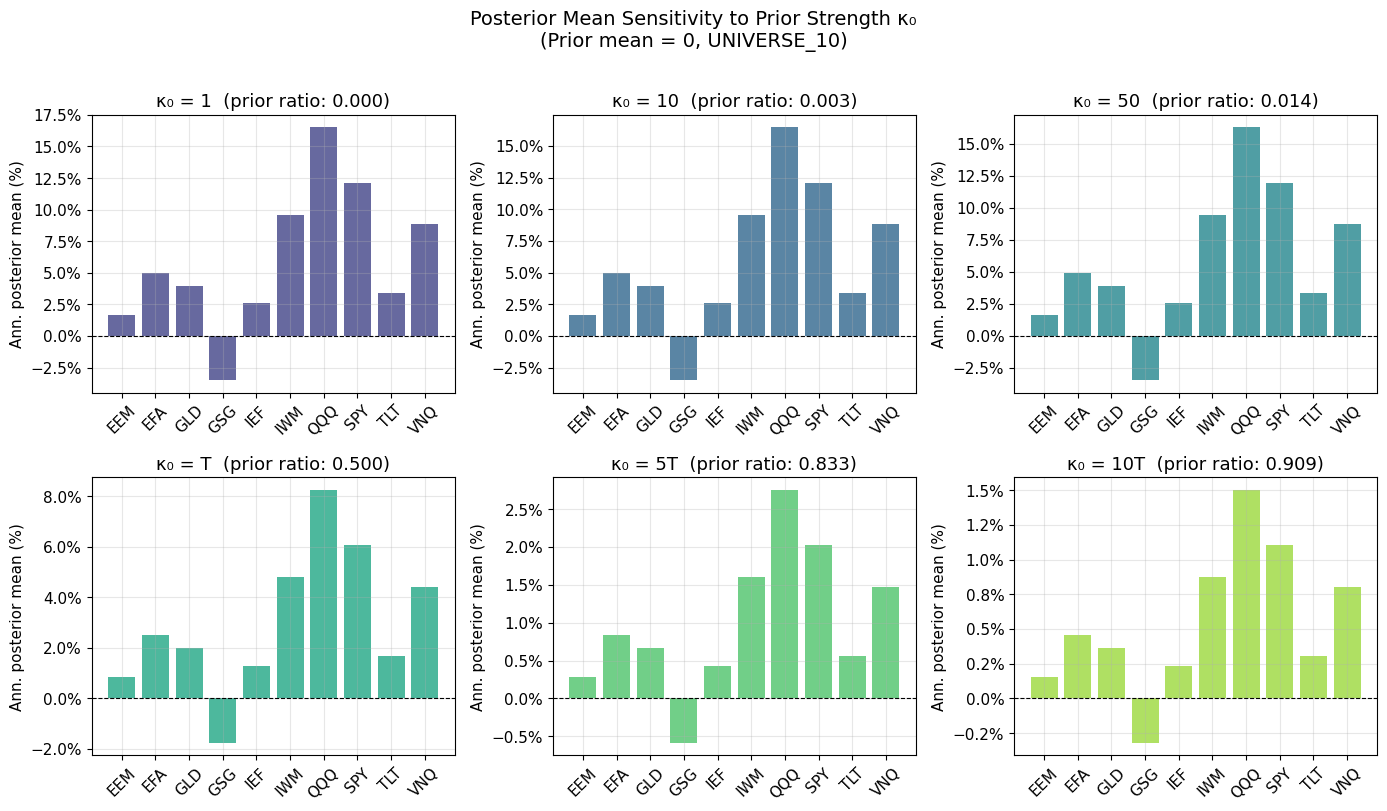

In [3]:
# Prior sensitivity: vary kappa_0
x_bar = X10.mean(axis=0)
kappa_0_values = [1, 10, 50, T10, 5*T10, 10*T10]
kappa_labels = ['1', '10', '50', 'T', '5T', '10T']

posteriors = {}
for kappa_0 in kappa_0_values:
    prior = NormalWishartPrior(
        mu_0=np.zeros(n10),
        kappa_0=float(kappa_0),
        nu_0=float(n10 + 2),
        Psi_0=np.eye(n10),
    )
    post = NormalWishartPosterior.update(prior, X10)
    posteriors[kappa_0] = post

# --- Figure: 2×3 grid of posterior mean bar charts ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(kappa_0_values)))

for ax, (kappa_0, label), color in zip(axes.flat, zip(kappa_0_values, kappa_labels), colors):
    post = posteriors[kappa_0]
    mu_n = post.posterior_mean() * 252  # annualise daily returns
    ratio = post.prior_strength_ratio()
    ax.bar(assets_10, mu_n, color=color, alpha=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_title(f'κ₀ = {label}  (prior ratio: {ratio:.3f})')
    ax.set_ylabel('Ann. posterior mean (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Posterior Mean Sensitivity to Prior Strength κ₀\n(Prior mean = 0, UNIVERSE_10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_prior_sensitivity_means.png'), dpi=300, bbox_inches='tight')
plt.show()

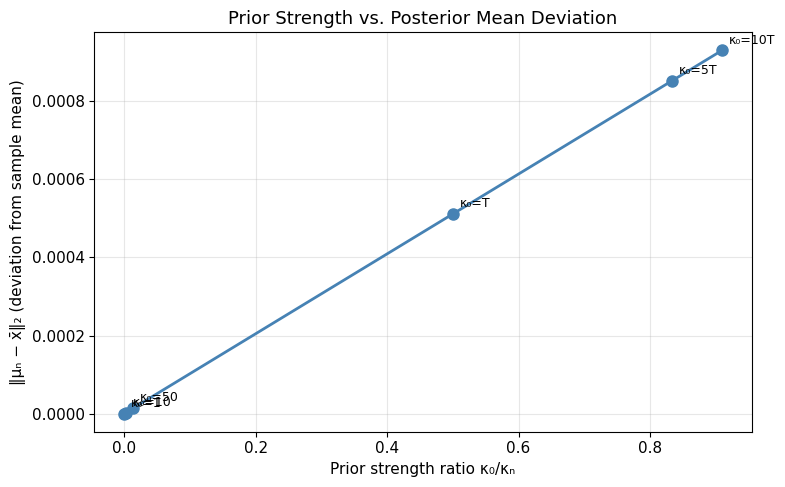

In [4]:
# Prior strength ratio vs. deviation from sample mean
ratios = [posteriors[k].prior_strength_ratio() for k in kappa_0_values]
deviations = [
    float(np.linalg.norm(posteriors[k].posterior_mean() - x_bar))
    for k in kappa_0_values
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ratios, deviations, 'o-', markersize=8, color='steelblue')
for r, d, label in zip(ratios, deviations, kappa_labels):
    ax.annotate(f'κ₀={label}', (r, d), textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('Prior strength ratio κ₀/κₙ')
ax.set_ylabel('‖μₙ − x̄‖₂ (deviation from sample mean)')
ax.set_title('Prior Strength vs. Posterior Mean Deviation')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_prior_strength_vs_deviation.png'), dpi=300, bbox_inches='tight')
plt.show()

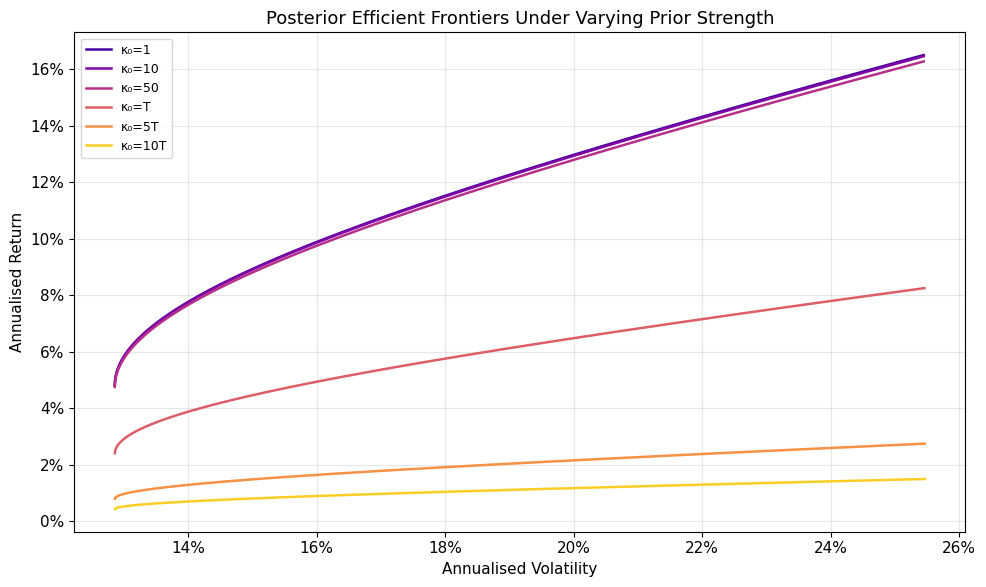

In [5]:
# Efficient frontiers for different prior strengths
fig, ax = plt.subplots(figsize=(10, 6))
colors_ef = plt.cm.plasma(np.linspace(0.1, 0.9, len(kappa_0_values)))

for (kappa_0, label), color in zip(zip(kappa_0_values, kappa_labels), colors_ef):
    post = posteriors[kappa_0]
    mu_n = post.posterior_mean()
    Sigma_n = post.posterior_covariance()
    try:
        ef = EfficientFrontier(mu=mu_n, Sigma=Sigma_n)
        frontier = ef.compute_frontier(n_points=150)
        ax.plot(
            frontier['portfolio_std'] * np.sqrt(252),
            frontier['portfolio_return'] * 252,
            color=color, linewidth=1.8,
            label=f'κ₀={label}'
        )
    except Exception as e:
        print(f'Skipping κ₀={label}: {e}')

ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Posterior Efficient Frontiers Under Varying Prior Strength')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_prior_sensitivity_frontiers.png'), dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** As $\kappa_0$ grows relative to $T$, the posterior mean $\mu_n$ is pulled toward the prior mean (zero). With very strong prior belief ($\kappa_0 = 10T$), the posterior frontier collapses toward the risk-free line through the origin — a purely Bayesian regularisation effect. With $\kappa_0 = 1$, the frontier closely tracks the sample estimate.

---
## Section 3: Black-Litterman with Views

I construct three views on UNIVERSE_10 and analyse the sensitivity of the BL posterior to view confidence.

In [6]:
# Fit sample covariance and construct BL model
sc_10 = SampleCovariance().fit(X10)
Sigma_10 = sc_10.covariance_

# Market-cap proxy: equal weights for simplicity
w_mkt_10 = np.ones(n10) / n10
delta = 2.5
tau = 1.0 / T10    # standard choice: 1/T

bl = BlackLitterman(Sigma=Sigma_10, w_mkt=w_mkt_10, delta=delta, tau=tau)
Pi = bl.Pi

print('Implied equilibrium returns Pi (annualised):')
for name, pi in zip(assets_10, Pi * 252):
    print(f'  {name:5s}: {pi:+.2%}')

Implied equilibrium returns Pi (annualised):
  EEM  : +5.66%
  EFA  : +5.02%
  GLD  : +1.42%
  GSG  : +3.63%
  IEF  : -0.13%
  IWM  : +5.91%
  QQQ  : +5.24%
  SPY  : +4.75%
  TLT  : -0.55%
  VNQ  : +5.13%


In [7]:
# --- Three investor views ---
# View 1: SPY outperforms TLT by 5% (equity risk premium)
# View 2: GLD outperforms GSG by 3% (gold vs commodities)
# View 3: QQQ outperforms IWM by 4% (large-cap tech vs small-cap)

idx = {name: i for i, name in enumerate(assets_10)}

P = np.zeros((3, n10))
P[0, idx['SPY']] = 1.0;  P[0, idx['TLT']] = -1.0   # View 1
P[1, idx['GLD']] = 1.0;  P[1, idx['GSG']] = -1.0   # View 2
P[2, idx['QQQ']] = 1.0;  P[2, idx['IWM']] = -1.0   # View 3

Q = np.array([0.05, 0.03, 0.04]) / 252   # daily returns
Omega = bl.default_omega(P)

print('Pick matrix P:')
print(pd.DataFrame(P, columns=assets_10, index=['View 1', 'View 2', 'View 3']).to_string())
print(f'\nView returns Q (daily): {Q}')
print(f'View returns Q (ann.): {Q * 252}')

Pick matrix P:
        EEM  EFA  GLD  GSG  IEF  IWM  QQQ  SPY  TLT  VNQ
View 1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0 -1.0  0.0
View 2  0.0  0.0  1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0
View 3  0.0  0.0  0.0  0.0  0.0 -1.0  1.0  0.0  0.0  0.0

View returns Q (daily): [0.00019841 0.00011905 0.00015873]
View returns Q (ann.): [0.05 0.03 0.04]


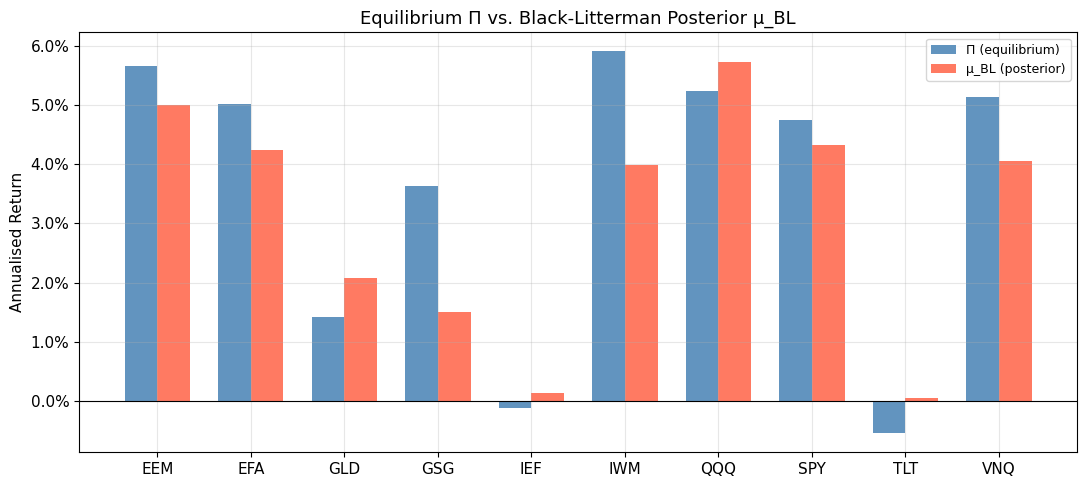

     Pi (equilibrium)  mu_BL (posterior)  Change
EEM             5.66%              5.01%  -0.65%
EFA             5.02%              4.24%  -0.78%
GLD             1.42%              2.08%   0.66%
GSG             3.63%              1.51%  -2.12%
IEF            -0.13%              0.14%   0.27%
IWM             5.91%              3.98%  -1.93%
QQQ             5.24%              5.74%   0.49%
SPY             4.75%              4.33%  -0.42%
TLT            -0.55%              0.04%   0.59%
VNQ             5.13%              4.05%  -1.08%


In [8]:
mu_BL, Sigma_BL = bl.posterior(P, Q, Omega)

# Compare Pi vs BL posterior
comparison = pd.DataFrame({
    'Pi (equilibrium)': Pi * 252,
    'mu_BL (posterior)': mu_BL * 252,
    'Change': (mu_BL - Pi) * 252,
}, index=assets_10)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(n10)
w = 0.35
ax.bar(x - w/2, Pi * 252, width=w, label='Π (equilibrium)', color='steelblue', alpha=0.85)
ax.bar(x + w/2, mu_BL * 252, width=w, label='μ_BL (posterior)', color='tomato', alpha=0.85)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(assets_10)
ax.set_ylabel('Annualised Return')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_title('Equilibrium Π vs. Black-Litterman Posterior μ_BL')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_bl_pi_vs_mbl.png'), dpi=300, bbox_inches='tight')
plt.show()
print(comparison.to_string(float_format='{:.2%}'.format))

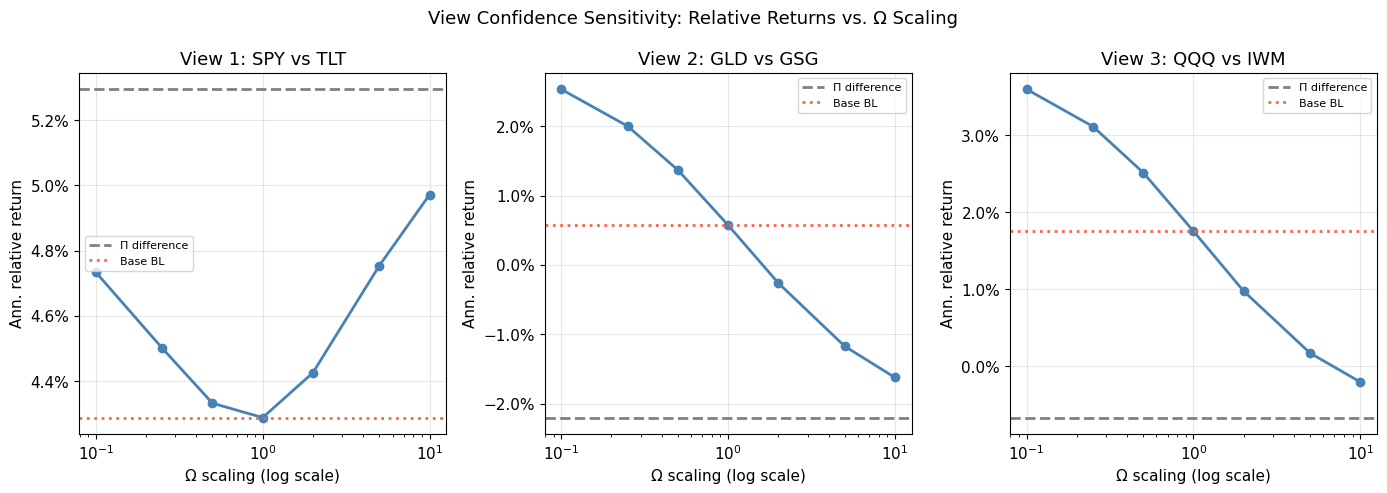

In [9]:
# View confidence sensitivity
scalings = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
sensitivity_df = bl.view_confidence_sensitivity(P, Q, scalings)
sensitivity_df.columns = assets_10
sensitivity_df.index.name = 'Omega scaling'

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
view_pairs = [('SPY', 'TLT'), ('GLD', 'GSG'), ('QQQ', 'IWM')]
view_names = ['View 1: SPY vs TLT', 'View 2: GLD vs GSG', 'View 3: QQQ vs IWM']

for ax, (a1, a2), title in zip(axes, view_pairs, view_names):
    rel_return = (sensitivity_df[a1] - sensitivity_df[a2]) * 252
    ax.semilogx(scalings, rel_return.values, 'o-', color='steelblue', linewidth=2)
    ax.axhline(float((Pi[idx[a1]] - Pi[idx[a2]]) * 252), color='grey', linestyle='--', label='Π difference')
    ax.axhline(float((mu_BL[idx[a1]] - mu_BL[idx[a2]]) * 252), color='tomato', linestyle=':', label='Base BL')
    ax.set_xlabel('Ω scaling (log scale)')
    ax.set_ylabel('Ann. relative return')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('View Confidence Sensitivity: Relative Returns vs. Ω Scaling', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_bl_confidence_sensitivity.png'), dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** As the Omega scaling increases (lower view confidence), the BL posterior reverts toward the equilibrium $\Pi$. With scaling → 0 (near-certain views), the posterior mean approaches the view-implied levels.

---
## Section 4: Covariance Estimator Comparison (UNIVERSE_30)

In [10]:
# Fetch UNIVERSE_30
returns_30 = fetch_universe_30()
X30 = returns_30.values
T30, n30 = X30.shape
assets_30 = list(returns_30.columns)
print(f'UNIVERSE_30: {T30} obs × {n30} assets ({returns_30.index[0].date()} – {returns_30.index[-1].date()})')

UNIVERSE_30: 3521 obs × 29 assets (2010-01-05 – 2023-12-29)


In [11]:
# Fit all three estimators
sc_30 = SampleCovariance().fit(X30)
lw_30 = LedoitWolfCovariance().fit(X30)
nw_30 = NormalWishartCovariance().fit(X30)

print(f'Sample   — cond: {sc_30.condition_number_:.1f}')
print(f'Ledoit-Wolf — α: {lw_30.shrinkage_intensity_:.4f}, cond: {lw_30.condition_number_:.1f}')
print(f'NW Bayes — prior ratio: {nw_30.prior_strength_ratio_:.4f}, cond: {nw_30.condition_number_:.1f}')

Sample   — cond: 115.8
Ledoit-Wolf — α: 0.0014, cond: 114.5
NW Bayes — prior ratio: 0.0003, cond: 15.2


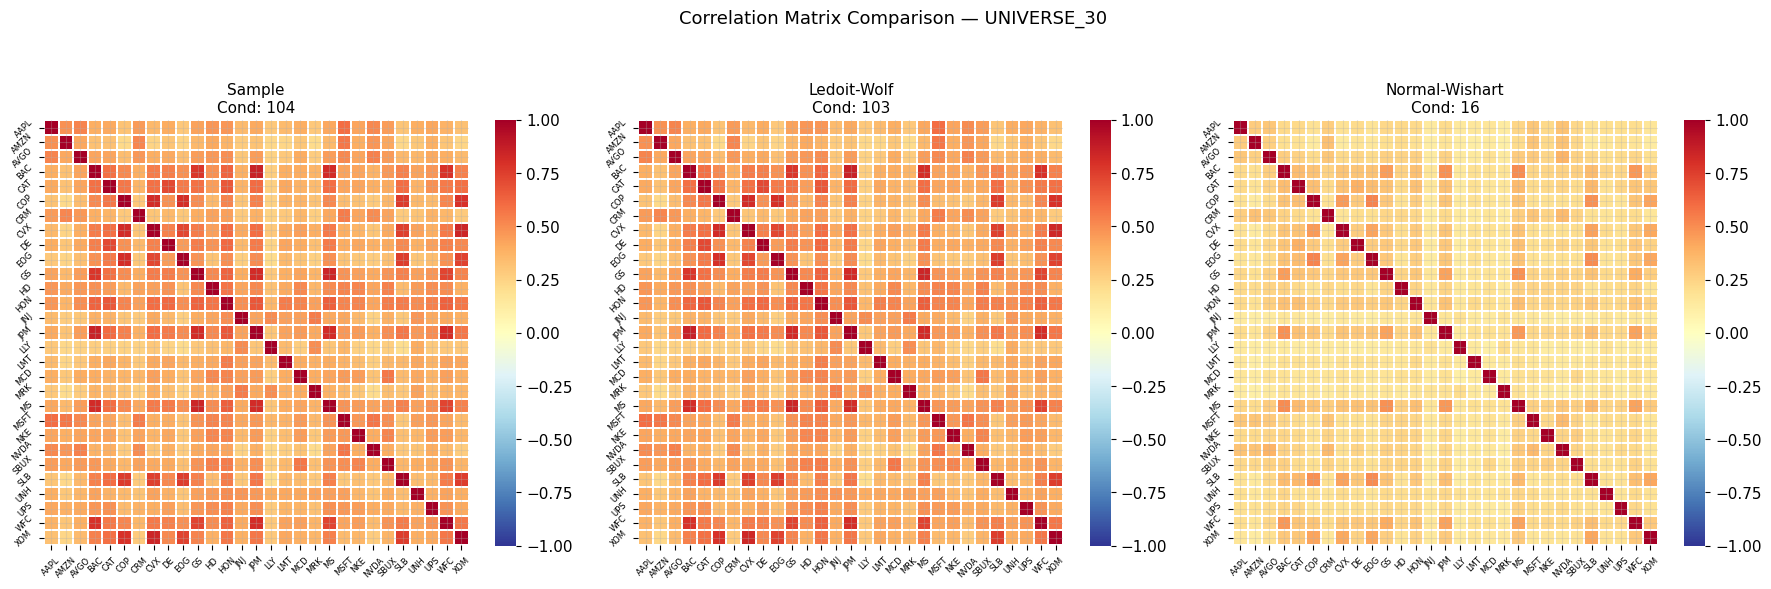

In [12]:
# Correlation heatmaps (1×3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
estimators_corr = [
    ('Sample', sc_30.correlation_),
    ('Ledoit-Wolf', lw_30.correlation_),
    ('Normal-Wishart', nw_30.correlation_),
]
for ax, (name, corr) in zip(axes, estimators_corr):
    sns.heatmap(
        corr,
        ax=ax,
        cmap='RdYlBu_r',
        center=0,
        vmin=-1, vmax=1,
        xticklabels=assets_30,
        yticklabels=assets_30,
        annot=False,
        square=True,
        linewidths=0.1,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{name}\nCond: {np.linalg.cond(corr):.0f}', fontsize=11)
    ax.tick_params(axis='both', labelsize=6, rotation=45)

fig.suptitle('Correlation Matrix Comparison — UNIVERSE_30', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_correlation_heatmaps.png'), dpi=300, bbox_inches='tight')
plt.show()

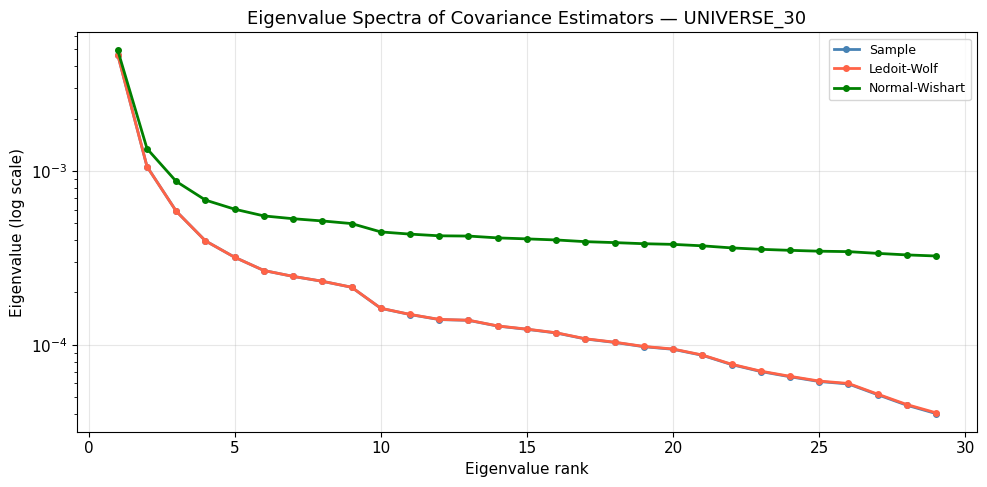


Covariance Estimator Summary:
                condition_number  min_eigenvalue  frobenius_from_sample
Sample                1.1582e+02      4.0166e-05             0.0000e+00
Ledoit-Wolf           1.1452e+02      4.0572e-05             6.1029e-06
Normal-Wishart        1.5227e+01      3.2408e-04             1.5285e-03


In [13]:
# Eigenvalue spectra
fig, ax = plt.subplots(figsize=(10, 5))
for name, est, color in [
    ('Sample', sc_30, 'steelblue'),
    ('Ledoit-Wolf', lw_30, 'tomato'),
    ('Normal-Wishart', nw_30, 'green'),
]:
    eigs = np.sort(np.linalg.eigvalsh(est.covariance_))[::-1]
    ax.semilogy(range(1, len(eigs)+1), eigs, 'o-', label=name, color=color, markersize=4)

ax.set_xlabel('Eigenvalue rank')
ax.set_ylabel('Eigenvalue (log scale)')
ax.set_title('Eigenvalue Spectra of Covariance Estimators — UNIVERSE_30')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_eigenvalue_spectra.png'), dpi=300, bbox_inches='tight')
plt.show()

# Summary table
summary_cov = pd.DataFrame({
    'Sample': {'condition_number': sc_30.condition_number_, 'min_eigenvalue': np.linalg.eigvalsh(sc_30.covariance_).min(), 'frobenius_from_sample': 0.0},
    'Ledoit-Wolf': {'condition_number': lw_30.condition_number_, 'min_eigenvalue': np.linalg.eigvalsh(lw_30.covariance_).min(), 'frobenius_from_sample': np.linalg.norm(lw_30.covariance_ - sc_30.covariance_, 'fro')},
    'Normal-Wishart': {'condition_number': nw_30.condition_number_, 'min_eigenvalue': np.linalg.eigvalsh(nw_30.covariance_).min(), 'frobenius_from_sample': np.linalg.norm(nw_30.covariance_ - sc_30.covariance_, 'fro')},
}).T
print('\nCovariance Estimator Summary:')
print(summary_cov.to_string(float_format='{:.4e}'.format))

---
## Section 5: Efficient Frontier Comparison (UNIVERSE_10)

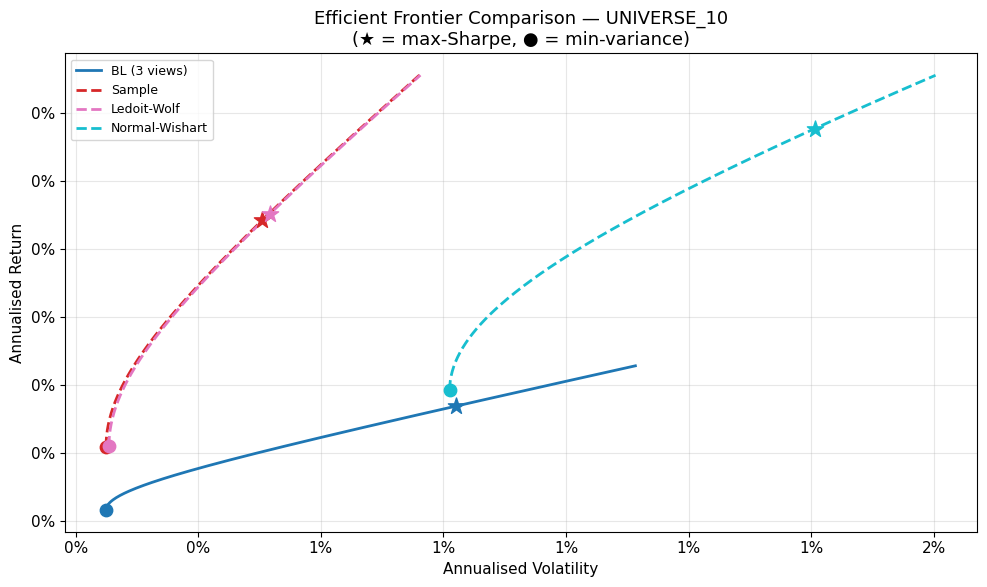

In [14]:
# Build four sets of (mu, Sigma) estimates
mu_sample = X10.mean(axis=0)

sc_10_est = SampleCovariance().fit(X10)
lw_10_est = LedoitWolfCovariance().fit(X10)
nw_10_est = NormalWishartCovariance().fit(X10)

# BL inputs (3 views from Section 3)
bl_10 = BlackLitterman(Sigma=sc_10_est.covariance_, w_mkt=w_mkt_10, delta=delta, tau=tau)
mu_bl_10, Sigma_bl_10 = bl_10.posterior(P, Q, Omega)

# NW posterior mean
prior_10 = NormalWishartPrior(mu_0=np.zeros(n10), kappa_0=1.0, nu_0=float(n10+2), Psi_0=np.eye(n10))
post_10 = NormalWishartPosterior.update(prior_10, X10)
mu_nw_10 = post_10.posterior_mean()

estimators_frontier = {
    'BL (3 views)':    (mu_bl_10, Sigma_bl_10),
    'Sample':          (mu_sample, sc_10_est.covariance_),
    'Ledoit-Wolf':     (mu_sample, lw_10_est.covariance_),
    'Normal-Wishart':  (mu_nw_10, nw_10_est.covariance_),
}

fc = FrontierComparison(estimators_frontier)

fig, ax = plt.subplots(figsize=(10, 6))
fc.plot_frontiers(ax=ax)
ax.set_title('Efficient Frontier Comparison — UNIVERSE_10\n(★ = max-Sharpe, ● = min-variance)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_frontier_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Max-Sharpe weights table
ms_table = fc.compare_max_sharpe()
print('Max-Sharpe Portfolio Comparison:')
print(ms_table[['return', 'volatility', 'sharpe']].to_string(float_format='{:.4f}'.format))

# HHI concentration metric
print('\nHHI Concentration (max-Sharpe weights):')
for name, ef in fc._ef_objects.items():
    try:
        w = ef.max_sharpe()
        hhi = float(np.sum(w**2))  # Herfindahl–Hirschman Index
        print(f'  {name:20s}: HHI = {hhi:.4f}  (1/HHI = {1/hhi:.1f} effective assets)')
    except ValueError:
        pass

Max-Sharpe Portfolio Comparison:
                return  volatility  sharpe
BL (3 views)    0.0002      0.0082  0.0205
Sample          0.0004      0.0050  0.0876
Ledoit-Wolf     0.0005      0.0052  0.0872
Normal-Wishart  0.0006      0.0141  0.0410

HHI Concentration (max-Sharpe weights):
  BL (3 views)        : HHI = 0.6455  (1/HHI = 1.5 effective assets)
  Sample              : HHI = 1.7203  (1/HHI = 0.6 effective assets)
  Ledoit-Wolf         : HHI = 1.6971  (1/HHI = 0.6 effective assets)
  Normal-Wishart      : HHI = 0.4178  (1/HHI = 2.4 effective assets)


**HHI Discussion:** The Herfindahl-Hirschman Index $\sum_i w_i^2$ measures portfolio concentration. A uniform portfolio has HHI = $1/n$; a single-asset portfolio has HHI = 1. Equivalently, $1/\text{HHI}$ gives the "effective number of assets." Unconstrained mean-variance optimisation tends to produce highly concentrated portfolios (low HHI denominator) due to parameter estimation error. The BL prior and shrinkage covariance both act as regularisers that typically improve HHI.

---
## Section 6: Walk-Forward Evaluation (UNIVERSE_30, 2015–2023)

In [16]:
# Filter UNIVERSE_30 to 2015-2023 for walk-forward
returns_wf = returns_30['2015-01-01':'2023-12-31'].copy()
print(f'Walk-forward dataset: {len(returns_wf)} obs × {len(returns_wf.columns)} assets')
print(f'Period: {returns_wf.index[0].date()} – {returns_wf.index[-1].date()}')

Walk-forward dataset: 2264 obs × 29 assets
Period: 2015-01-02 – 2023-12-29


In [17]:
# Walk-forward: train=252, test=63, stride=21
wf_estimators = {
    'sample': SampleCovariance,
    'lw': LedoitWolfCovariance,
    'nw': NormalWishartCovariance,
}

ev = WalkForwardEvaluator(train_window=252, test_window=63, stride=21)
ev.run(returns_wf, wf_estimators, optimizer='max_sharpe')

summary = ev.summary()
print('Walk-Forward Performance Summary (Annualised):')
print(summary[['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover', 'hit_rate', 'n_folds']].to_string(
    float_format='{:.4f}'.format
))

Walk-Forward Performance Summary (Annualised):
        ann_return  ann_vol  sharpe  max_drawdown  turnover  hit_rate  n_folds
sample     -0.8543   8.3977 -0.1017     -104.1507   52.6196    0.5242  93.0000
lw         -0.9560   9.8269 -0.0973    -1415.0887   46.0132    0.5218  93.0000
nw          0.5823   3.6339  0.1602       -1.0571   11.2674    0.5388  93.0000


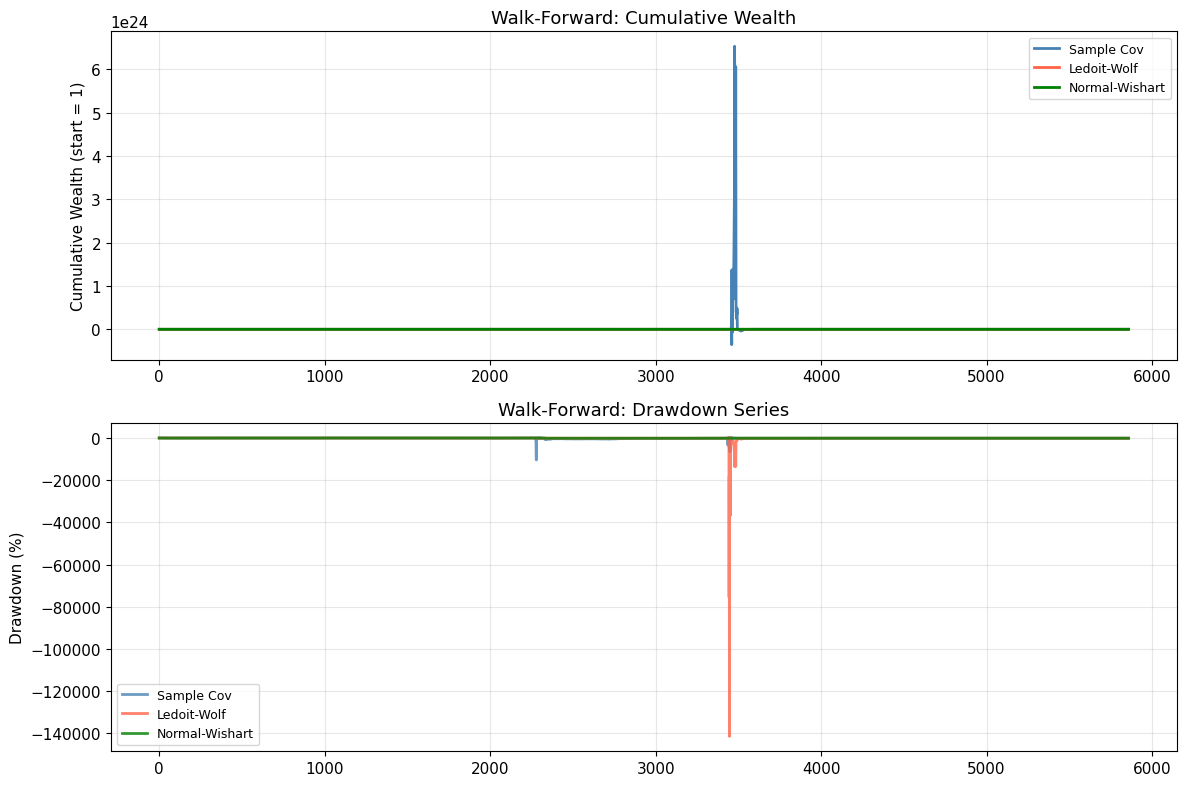

In [18]:
# Cumulative wealth and drawdown plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

colors_wf = {'sample': 'steelblue', 'lw': 'tomato', 'nw': 'green'}
labels_wf = {'sample': 'Sample Cov', 'lw': 'Ledoit-Wolf', 'nw': 'Normal-Wishart'}

for name in wf_estimators:
    r = ev.portfolio_returns(name)
    cum_wealth = np.cumprod(1.0 + r)
    axes[0].plot(cum_wealth, label=labels_wf[name], color=colors_wf[name])

axes[0].set_ylabel('Cumulative Wealth (start = 1)')
axes[0].set_title('Walk-Forward: Cumulative Wealth')
axes[0].legend()

for name in wf_estimators:
    dd = ev.drawdown_series(name).values
    axes[1].plot(dd * 100, label=labels_wf[name], color=colors_wf[name], alpha=0.8)

axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Walk-Forward: Drawdown Series')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_walkforward_wealth_drawdown.png'), dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Diebold-Mariano tests vs. sample covariance baseline
dm_results = ev.statistical_tests(baseline='sample')
print('Diebold-Mariano Tests vs. Sample Covariance Baseline:')
print('(H0: equal predictive accuracy; positive DM = alternative outperforms baseline)')
print(dm_results[['dm_statistic', 'p_value', 'significant_5pct', 'T']].to_string(float_format='{:.4f}'.format))
print()
print('C9 reminder: Only claim outperformance when p-value < 0.05.')
for name in dm_results.index:
    row = dm_results.loc[name]
    sig = 'SIGNIFICANT' if row['significant_5pct'] else 'not significant'
    direction = 'outperforms' if row['dm_statistic'] > 0 else 'underperforms'
    print(f'  {name:25s}: {direction} Sample (DM={row["dm_statistic"]:.3f}, p={row["p_value"]:.4f}, {sig})')

Diebold-Mariano Tests vs. Sample Covariance Baseline:
(H0: equal predictive accuracy; positive DM = alternative outperforms baseline)
   dm_statistic p_value significant_5pct     T
lw       3.4449  0.0006             True  5859
nw      -4.6298  0.0000             True  5859

C9 reminder: Only claim outperformance when p-value < 0.05.
  lw                       : outperforms Sample (DM=3.445, p=0.0006, SIGNIFICANT)
  nw                       : underperforms Sample (DM=-4.630, p=0.0000, SIGNIFICANT)


---
## Section 7: Two-Fund Separation (UNIVERSE_10 with BL Inputs)

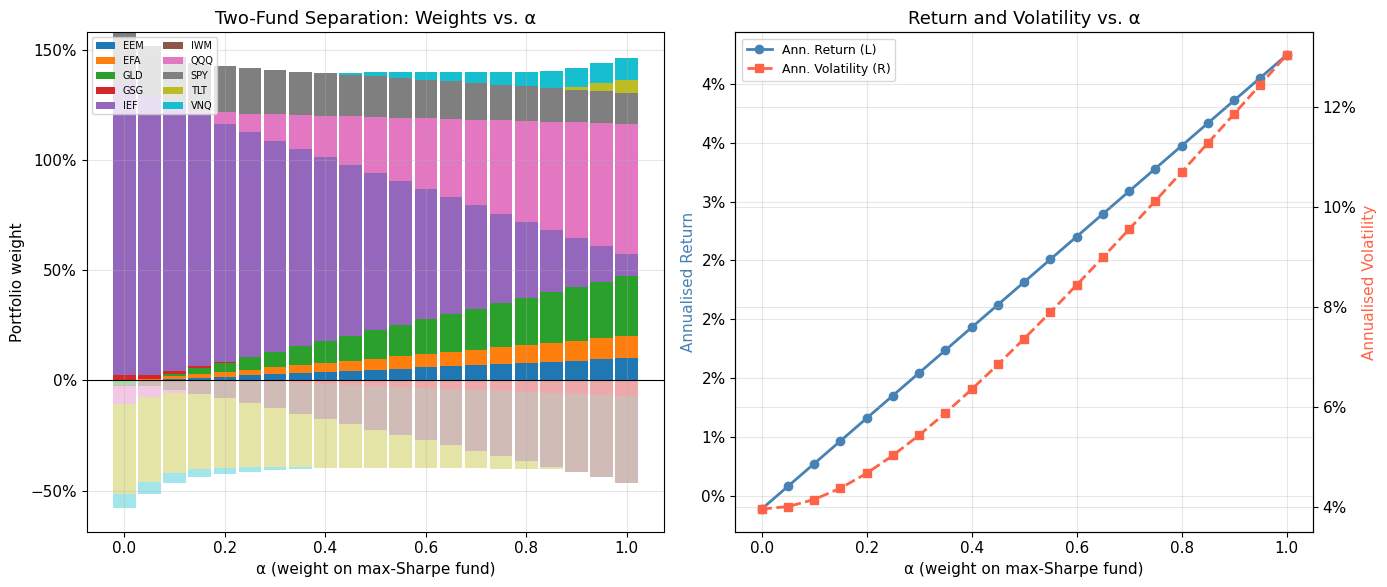

In [20]:
# Two-fund separation using BL posterior inputs
ef_bl = EfficientFrontier(mu=mu_bl_10, Sigma=Sigma_bl_10)

alphas = np.linspace(0, 1, 21)
tfs_returns = []
tfs_vols = []
tfs_weights = []

for alpha in alphas:
    w = ef_bl.two_fund_separation(alpha)
    r = float(w @ mu_bl_10)
    vol = float(np.sqrt(w @ Sigma_bl_10 @ w))
    tfs_returns.append(r * 252)
    tfs_vols.append(vol * np.sqrt(252))
    tfs_weights.append(w)

# Stacked bar chart of weights vs. alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

weights_arr = np.array(tfs_weights)
colors_bar = plt.cm.tab10(np.linspace(0, 0.9, n10))
bottom = np.zeros(len(alphas))
pos_bottom = np.zeros(len(alphas))
neg_bottom = np.zeros(len(alphas))

for j, (asset, color) in enumerate(zip(assets_10, colors_bar)):
    w_j = weights_arr[:, j]
    pos_w = np.maximum(w_j, 0)
    neg_w = np.minimum(w_j, 0)
    axes[0].bar(alphas, pos_w, bottom=pos_bottom, width=0.045, color=color, label=asset if j < n10 else '')
    axes[0].bar(alphas, neg_w, bottom=neg_bottom, width=0.045, color=color, alpha=0.4)
    pos_bottom += pos_w
    neg_bottom += neg_w

axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].set_xlabel('α (weight on max-Sharpe fund)')
axes[0].set_ylabel('Portfolio weight')
axes[0].set_title('Two-Fund Separation: Weights vs. α')
axes[0].legend(fontsize=7, loc='upper left', ncol=2)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Return/vol vs. alpha
ax2b = axes[1].twinx()
axes[1].plot(alphas, tfs_returns, 'o-', color='steelblue', label='Ann. Return (L)')
ax2b.plot(alphas, tfs_vols, 's--', color='tomato', label='Ann. Volatility (R)')
axes[1].set_xlabel('α (weight on max-Sharpe fund)')
axes[1].set_ylabel('Annualised Return', color='steelblue')
ax2b.set_ylabel('Annualised Volatility', color='tomato')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2b.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('Return and Volatility vs. α')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_two_fund_separation.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## Section 8: Limitations

### 8.1 Gaussianity

The entire framework — Normal-Wishart conjugacy, Black-Litterman, and mean-variance optimisation — assumes multivariate normally distributed returns. In practice, financial returns exhibit **fat tails** (excess kurtosis), **negative skewness**, and **volatility clustering** (ARCH effects). The Normal-Wishart posterior mean of the covariance is sensitive to outliers in ways the Gaussian model cannot account for: a single market crash day inflates the scatter matrix $S$ and thereby shifts the posterior covariance dramatically. Robust alternatives such as the Student-t distribution or heavy-tailed elliptical distributions exist but sacrifice conjugacy, requiring approximate inference.

### 8.2 Stationarity

The conjugate posterior update treats all $T$ observations as i.i.d. draws from a fixed $\mathcal{N}(\mu, \Sigma)$. Real markets are **non-stationary**: correlations spike during crises (e.g., COVID-19 in March 2020), expected returns shift with macro regimes, and volatilities exhibit long-memory. A fixed training window implicitly assumes the most recent 252 days are equally informative as all previous days. Regime-switching models, time-varying parameter models, or the Wishart process (continuous-time) better capture this non-stationarity, but at a significant increase in model complexity and computational cost.

### 8.3 Sensitivity to δ and w_mkt

The Black-Litterman equilibrium prior $\Pi = \delta \Sigma w_{\text{mkt}}$ is critically sensitive to two inputs that are not estimated from data: the risk aversion $\delta$ and the market portfolio weights $w_{\text{mkt}}$. In practice, $\delta$ is typically calibrated to the Sharpe ratio of the market portfolio, but this calibration is itself noisy. Using equal weights as a proxy for $w_{\text{mkt}}$ (as done here) ignores the actual capitalisation-weighted market, which can differ substantially. Any misspecification in these inputs propagates directly into the posterior mean and hence into all subsequent portfolio allocations.

### 8.4 Garbage-in, Garbage-out

The Bayesian framework provides a principled way to blend prior beliefs with data, but it cannot compensate for poor-quality inputs. The view returns $Q$ in the Black-Litterman model are investor-specified; if the views are economically wrong, the posterior mean will be wrong in a direction coherent with the prior — a false sense of Bayesian rigour. Similarly, the prior hyperparameters $(\mu_0, \kappa_0, \nu_0, \Psi_0)$ must be chosen thoughtfully; vague uninformative priors with small $\kappa_0$ and $\nu_0$ provide little regularisation and the posterior converges to the sample estimate, inheriting all its estimation error.

### 8.5 High-Dimensional Scaling

For large universes ($n \gg 30$), several components of this framework become computationally and statistically challenging. The bordered Hessian KKT system is $(n+2) \times (n+2)$; the BL master formula requires solving $n \times n$ systems. More critically, the covariance matrix has $n(n+1)/2$ parameters; with $T$ observations, the ratio $T/n$ must be significantly larger than 1 for reliable estimation. For $n = 100$ with $T = 252$ trading days (one year), the sample covariance is poorly conditioned ($T/n = 2.52$), making regularisation (Ledoit-Wolf or Bayesian shrinkage) essential. The Normal-Wishart prior requires $\nu_0 > n-1$ for propriety, so even the weakly informative prior becomes non-trivial in high dimensions. Structured covariance models (factor models, sparse precision matrices) are better suited for $n > 100$.

In [21]:
# Verify all figures were saved
import glob
saved_figures = sorted(glob.glob(os.path.join(FIGURES_DIR, '*.png')))
print(f'Figures saved ({len(saved_figures)} total):')
for f in saved_figures:
    print(f'  {os.path.basename(f)}')

Figures saved (10 total):
  01_prior_sensitivity_means.png
  02_prior_strength_vs_deviation.png
  03_prior_sensitivity_frontiers.png
  04_bl_pi_vs_mbl.png
  05_bl_confidence_sensitivity.png
  06_correlation_heatmaps.png
  07_eigenvalue_spectra.png
  08_frontier_comparison.png
  09_walkforward_wealth_drawdown.png
  10_two_fund_separation.png
